## Libraries

In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

## Plot - after 5ns

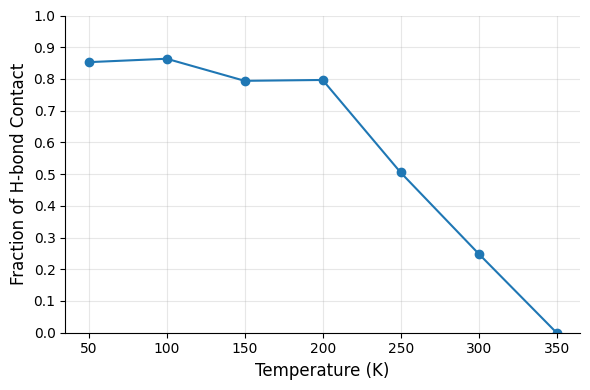

In [50]:
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234  #6468305 steps = 10ns / 2 - drop early equilibration
max_pairs = 34         
temps     = []
fractions = []

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    # 1) drop early frames
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        print(f"⚠️ {f.name} has no data after frame {start_frame}, skipping")
        continue
    
    # 2) compute average fraction of possible contacts
    #    this gives a number between 0 and 1
    frac = df2['NumContacts'].mean() / max_pairs

    # 3) parse temperature from filename
    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temp = int(m.group(1))
    
    temps.append(temp)
    fractions.append(frac)

# assemble & sort
df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact Fraction': fractions
}).sort_values('Temperature (K)')

# plot
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(df_frac['Temperature (K)'],
        df_frac['Contact Fraction'],
        marker='o', linestyle='-')

ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Fraction of H-bond Contact', fontsize=12)
ax.set_ylim(0, 1)                         
ax.set_yticks(np.linspace(0, 1, 11))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Standard Deviation calc

In [73]:
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234  #6468305 steps = 10ns / 2 - drop early equilibration

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        continue
    std_contacts = df2['NumContacts'].std(ddof=1)
    m = re.search(r'(\d+)K', f.stem)
    temp = int(m.group(1)) if m else f.stem
    print(f"{temp} K: std of NumContacts = {std_contacts:.2f}")


50 K: std of NumContacts = 0.00
100 K: std of NumContacts = 0.48
150 K: std of NumContacts = 0.05
200 K: std of NumContacts = 1.99
250 K: std of NumContacts = 1.87
300 K: std of NumContacts = 2.22
350 K: std of NumContacts = 0.00


### Plot error bars as STD 

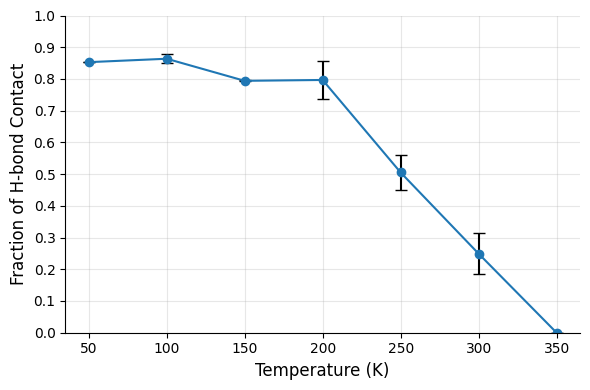

In [77]:
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234  #6468305 steps = 10ns / 2 - drop early equilibration
max_pairs = 34      
temps      = []
fractions  = []
errors     = []

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        print(f"⚠️ {f.name} has no data after frame {start_frame}, skipping")
        continue

    # mean fraction
    frac = df2['NumContacts'].mean() / max_pairs
    # std of fraction
    std_frac = df2['NumContacts'].std(ddof=1) / max_pairs

    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temp = int(m.group(1))

    temps.append(temp)
    fractions.append(frac)
    errors.append(std_frac)

df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact Fraction': fractions,
    'Std Fraction': errors
}).sort_values('Temperature (K)')

fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(
    df_frac['Temperature (K)'],
    df_frac['Contact Fraction'],
    yerr=df_frac['Std Fraction'],
    marker='o',
    linestyle='-',
    ecolor='black',
    capsize=4
)

ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Fraction of H-bond Contact', fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 11))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Fitting in a sigmoid shape

Fitted Tm = 244.71 K, slope = 50.25


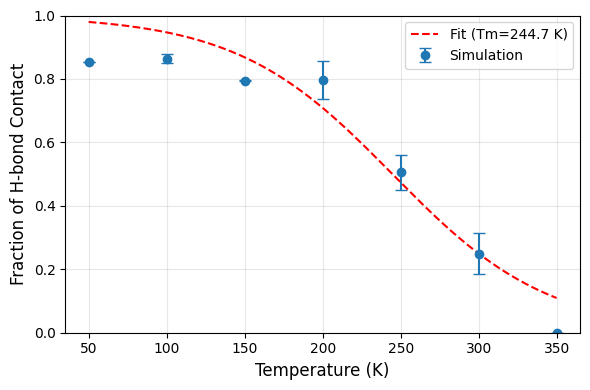

In [83]:
# Load and process data
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234
max_pairs = 34

temps, fractions, errors = [], [], []
for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        continue
    frac = df2['NumContacts'].mean() / max_pairs
    std_frac = df2['NumContacts'].std(ddof=1) / max_pairs
    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temps.append(int(m.group(1)))
    fractions.append(frac)
    errors.append(std_frac)

df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact Fraction': fractions,
    'Std Fraction': errors
}).sort_values('Temperature (K)')

T = df_frac['Temperature (K)'].values
F = df_frac['Contact Fraction'].values

# Define melting (sigmoidal) curve
def melting_curve(T, Tm, k):
    return 1.0 / (1.0 + np.exp((T - Tm) / k))

# Fit curve
popt, pcov = curve_fit(melting_curve, T, F, p0=[np.median(T), 5.0])
Tm_fit, k_fit = popt
print(f"Fitted Tm = {Tm_fit:.2f} K, slope = {k_fit:.2f}")

# Plot data with fit
T_fit = np.linspace(T.min(), T.max(), 200)
F_fit = melting_curve(T_fit, Tm_fit, k_fit)

fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(
    T, F, yerr=df_frac['Std Fraction'].values,
    marker='o', linestyle='None', capsize=4, label='Simulation'
)
ax.plot(T_fit, F_fit, 'r--', label=f'Fit (Tm={Tm_fit:.1f} K)')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Fraction of H-bond Contact', fontsize=12)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Percentage Plot

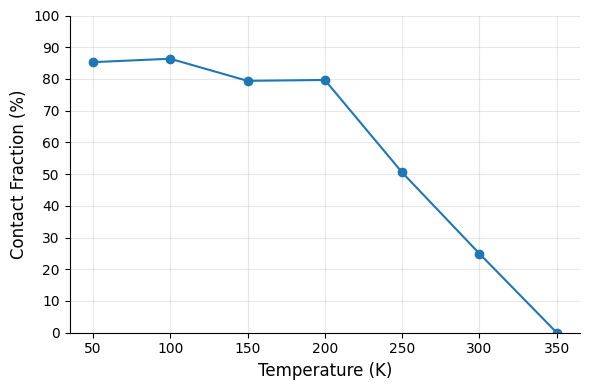

In [80]:
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234 #6468305 steps = 10ns / 2 - drop early equilibration

max_pairs = 34     
temps       = []
percents    = []
errors_pct  = []

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        print(f"⚠️ {f.name} has no data after frame {start_frame}, skipping")
        continue

    # mean fraction 
    frac_mean = df2['NumContacts'].mean() / max_pairs

    # convert to percent
    pct_mean = frac_mean * 100

    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temp = int(m.group(1))

    temps.append(temp)
    percents.append(pct_mean)

# assemble & sort
df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact (%)':      percents
}).sort_values('Temperature (K)')

# plot on 0–100 scale
fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(
    df_frac['Temperature (K)'],
    df_frac['Contact (%)'],
    marker='o',
    linestyle='-',
    capsize=4,
    ecolor='orange',
    elinewidth=1.5
)

ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Contact Fraction (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks(np.linspace(0, 100, 11))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Fitting in a sigmoid shape

Fitted Tm = 244.71 K, slope = 50.25


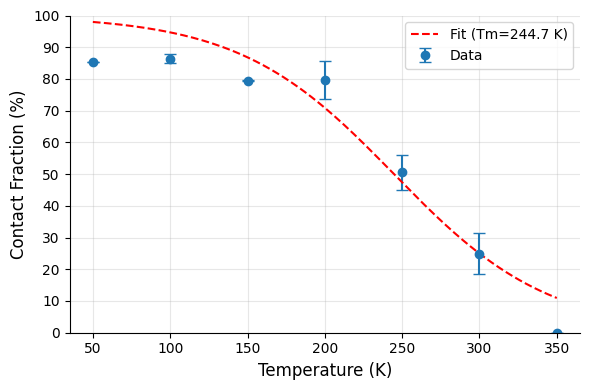

In [82]:
# Load & process
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234
max_pairs = 34

temps, percents, errors_pct = [], [], []

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        continue

    # mean fraction → percent
    frac_mean = df2['NumContacts'].mean() / max_pairs
    pct_mean  = frac_mean * 100

    # std of fraction → percent
    std_frac = df2['NumContacts'].std(ddof=1) / max_pairs
    pct_std  = std_frac * 100

    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temp = int(m.group(1))

    temps.append(temp)
    percents.append(pct_mean)
    errors_pct.append(pct_std)

df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact (%)':      percents,
    'Std (%)':          errors_pct
}).sort_values('Temperature (K)')

# Prepare data for fitting
T = df_frac['Temperature (K)'].values
P = df_frac['Contact (%)'].values

# Sigmoid in percent
def melting_curve_pct(T, Tm, k):
    return 100.0 / (1.0 + np.exp((T - Tm) / k))

# Fit
popt, pcov = curve_fit(melting_curve_pct, T, P, p0=[np.median(T), 5.0])
Tm_fit, k_fit = popt
print(f"Fitted Tm = {Tm_fit:.2f} K, slope = {k_fit:.2f}")

# Generate fit line
T_fit = np.linspace(T.min(), T.max(), 200)
P_fit = melting_curve_pct(T_fit, Tm_fit, k_fit)

# Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(
    df_frac['Temperature (K)'],
    df_frac['Contact (%)'],
    yerr=df_frac['Std (%)'],
    marker='o',
    linestyle='None',
    capsize=4,
    label='Data'
)
ax.plot(
    T_fit,
    P_fit,
    'r--',
    label=f'Fit (Tm={Tm_fit:.1f} K)'
)

ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Contact Fraction (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks(np.linspace(0, 100, 11))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
